# Stage 4: SOTA Mammography Preprocessing Pipeline

## Advanced Preprocessing for State-of-the-Art Performance

This notebook implements a SOTA preprocessing pipeline designed to maximize classification performance on CBIS-DDSM.

### Key Improvements over Stage 1-3 Preprocessing:

| Step | Technique | Purpose | Reference |
|------|-----------|---------|----------|
| 1 | Artifact Removal | Remove scanner labels (L, R, CC, MLO text) | Shen et al. (2019) |
| 2 | Breast Segmentation | Extract breast contour using Otsu's thresholding | Wang et al. (2020) |
| 3 | ROI Extraction | Crop to breast region with padding | Wu et al. (2019) |
| 4 | CLAHE Enhancement | Adaptive histogram equalization | Pizer et al. (1987) |
| 5 | Breast-Only Normalization | Normalize using breast tissue stats only | Shen et al. (2021) |
| 6 | Higher Resolution | 768x768 output for better detail preservation | McKinney et al. (2020) |

### Literature References:

1. **Shen et al. (2019)** - "Deep Learning to Improve Breast Cancer Detection on Screening Mammography" - NYU preprocessing pipeline
2. **Wang et al. (2020)** - "Breast Mass Detection in Digital Mammography" - Breast segmentation techniques
3. **Wu et al. (2019)** - "Breast Density Classification with Deep Convolutional Neural Networks" - ROI extraction
4. **Pizer et al. (1987)** - "Adaptive Histogram Equalization and Its Variations" - CLAHE algorithm
5. **McKinney et al. (2020)** - "International Evaluation of an AI System for Breast Cancer Screening" - Google Health preprocessing
6. **Lee et al. (2017)** - "A Curated Mammography Data Set for Use in Computer-Aided Detection" - CBIS-DDSM dataset

## 1. Setup and Imports

In [1]:
import os
import sys
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass, field
from collections import defaultdict
import json
from datetime import datetime
import time

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import pydicom

from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

print("STAGE 4 PREPROCESSING ENVIRONMENT")
print("=" * 60)
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"PyDicom version: {pydicom.__version__}")
print("\nAll imports successful!")

STAGE 4 PREPROCESSING ENVIRONMENT
Python version: 3.13.5
NumPy version: 2.1.3
Pandas version: 2.2.3
OpenCV version: 4.12.0
PyDicom version: 3.0.1

All imports successful!


## 2. Configuration

### Key Parameters:
- **Target Size**: 768x768 (higher resolution than Stage 1-3's 512x512)
- **Artifact Removal**: Enabled by default
- **Breast-Only Normalization**: Enabled by default

In [2]:
@dataclass
class Stage4PreprocessingConfig:
    """
    Stage 4 SOTA Preprocessing Configuration.
    
    Key differences from Stage 1-3:
    - Higher resolution output (768x768 vs 512x512)
    - Artifact removal enabled
    - Breast-only normalization
    - Multi-view pair tracking
    """
    # Input/Output Paths
    data_root: str = r"D:\Project\data\manifest-ZkhPvrLo5216730872708713142"
    output_root: str = r"D:\Project\data\stage4_preprocessed"
    
    # Image Processing - Higher Resolution for SOTA
    target_size: Tuple[int, int] = (768, 768)  # Higher than Stage 1-3 (512x512)
    roi_padding: float = 0.10  # 10% padding around breast region
    
    # CLAHE Parameters (Pizer et al., 1987)
    clahe_clip_limit: float = 2.0
    clahe_tile_grid_size: Tuple[int, int] = (8, 8)
    
    # Artifact Removal Settings (Shen et al., 2019)
    remove_artifacts: bool = True
    corner_mask_size: float = 0.15  # Mask 15% of corners for text removal
    
    # Breast-Only Normalization (Shen et al., 2021)
    breast_only_norm: bool = True
    
    # Split Parameters
    train_ratio: float = 0.80
    test_ratio: float = 0.20
    random_seed: int = 42
    
    # Processing Options
    use_roi_cropping: bool = True
    save_visualization: bool = True
    
    def __post_init__(self):
        """Initialize derived paths and create output directories."""
        self.cbis_ddsm_path = os.path.join(self.data_root, "CBIS-DDSM")
        self.output_train = os.path.join(self.output_root, "train")
        self.output_test = os.path.join(self.output_root, "test")
        
        # Create output directory structure
        for split in [self.output_train, self.output_test]:
            for label in ['benign', 'malignant']:
                os.makedirs(os.path.join(split, label), exist_ok=True)


config = Stage4PreprocessingConfig()

print("STAGE 4 PREPROCESSING CONFIGURATION")
print("=" * 60)
print(f"Data Root:              {config.data_root}")
print(f"Output Root:            {config.output_root}")
print(f"Target Size:            {config.target_size[0]}x{config.target_size[1]} pixels")
print(f"ROI Padding:            {config.roi_padding * 100}%")
print(f"CLAHE Clip Limit:       {config.clahe_clip_limit}")
print(f"CLAHE Tile Grid:        {config.clahe_tile_grid_size}")
print(f"Artifact Removal:       {config.remove_artifacts}")
print(f"Breast-Only Norm:       {config.breast_only_norm}")
print(f"Train/Test Split:       {config.train_ratio*100}% / {config.test_ratio*100}%")
print(f"Random Seed:            {config.random_seed}")

STAGE 4 PREPROCESSING CONFIGURATION
Data Root:              D:\Project\data\manifest-ZkhPvrLo5216730872708713142
Output Root:            D:\Project\data\stage4_preprocessed
Target Size:            768x768 pixels
ROI Padding:            10.0%
CLAHE Clip Limit:       2.0
CLAHE Tile Grid:        (8, 8)
Artifact Removal:       True
Breast-Only Norm:       True
Train/Test Split:       80.0% / 20.0%
Random Seed:            42


## 3. Data Structures and Core Functions

In [3]:
@dataclass
class ImageRecord:
    """Data class to store information about each mammography image."""
    patient_id: str
    image_type: str  # 'mass' or 'calc'
    laterality: str  # 'LEFT' or 'RIGHT'
    view: str  # 'CC' or 'MLO'
    abnormality_id: int
    pathology: str  # 'MALIGNANT', 'BENIGN', 'BENIGN_WITHOUT_CALLBACK'
    full_mammogram_path: str
    cropped_image_path: Optional[str] = None
    roi_mask_path: Optional[str] = None
    original_set: str = ""
    processed_path: str = ""
    split: str = ""
    
    @property
    def label(self) -> str:
        return 'malignant' if 'MALIGNANT' in self.pathology else 'benign'
    
    @property
    def label_binary(self) -> int:
        return 1 if 'MALIGNANT' in self.pathology else 0
    
    @property
    def view_id(self) -> str:
        """Unique identifier for multi-view pairing."""
        return f"{self.patient_id}_{self.laterality}_{self.view}"


@dataclass
class PreprocessingStats:
    """Statistics tracker for preprocessing pipeline."""
    total_images: int = 0
    processed_images: int = 0
    failed_images: int = 0
    train_benign: int = 0
    train_malignant: int = 0
    test_benign: int = 0
    test_malignant: int = 0
    avg_original_size: Tuple[float, float] = (0.0, 0.0)
    processing_time_seconds: float = 0.0
    artifacts_removed: int = 0
    
    def to_dict(self) -> Dict:
        return {
            'total_images': self.total_images,
            'processed_images': self.processed_images,
            'failed_images': self.failed_images,
            'train_benign': self.train_benign,
            'train_malignant': self.train_malignant,
            'test_benign': self.test_benign,
            'test_malignant': self.test_malignant,
            'avg_original_size': list(self.avg_original_size),
            'processing_time_seconds': self.processing_time_seconds,
            'artifacts_removed': self.artifacts_removed
        }


print("Data structures defined!")

Data structures defined!


## 4. DICOM Reading and Path Resolution

In [4]:
def resolve_dicom_path(relative_path: str, cbis_ddsm_path: str) -> str:
    """Resolve the DICOM file path from CSV relative path."""
    if pd.isna(relative_path) or str(relative_path) == 'nan':
        return ""
    relative_path = str(relative_path).strip().strip('"')
    parts = relative_path.replace('\\', '/').split('/')
    folder_name = parts[0]
    folder_path = os.path.join(cbis_ddsm_path, folder_name)
    if os.path.exists(folder_path):
        for root, dirs, files in os.walk(folder_path):
            for f in files:
                if f.endswith('.dcm'):
                    return os.path.join(root, f)
    return ""


def read_dicom(dicom_path: str) -> Optional[np.ndarray]:
    """
    Read a DICOM file and return normalized uint8 image.
    
    Handles:
    - MONOCHROME1 inversion
    - Window/level adjustments
    - Normalization to 0-255 range
    """
    if not dicom_path or not os.path.exists(dicom_path):
        return None
    try:
        dcm = pydicom.dcmread(dicom_path, force=True)
        if not hasattr(dcm, 'pixel_array'):
            return None
        img = dcm.pixel_array.astype(np.float32)
        
        # Handle MONOCHROME1 (inverted)
        if hasattr(dcm, 'PhotometricInterpretation'):
            if dcm.PhotometricInterpretation == 'MONOCHROME1':
                img = img.max() - img
        
        # Apply window/level if available
        if hasattr(dcm, 'WindowCenter') and hasattr(dcm, 'WindowWidth'):
            center = dcm.WindowCenter
            width = dcm.WindowWidth
            if isinstance(center, pydicom.multival.MultiValue):
                center = center[0]
            if isinstance(width, pydicom.multival.MultiValue):
                width = width[0]
            img_min = center - width // 2
            img_max = center + width // 2
            img = np.clip(img, img_min, img_max)
        
        # Normalize to 0-255
        if img.max() > img.min():
            img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
        else:
            img = np.zeros_like(img, dtype=np.uint8)
        return img
    except Exception as e:
        return None


def read_roi_mask(mask_path: str) -> Optional[np.ndarray]:
    """Read ROI mask from DICOM file."""
    if not mask_path or not os.path.exists(mask_path):
        return None
    try:
        dcm = pydicom.dcmread(mask_path, force=True)
        if hasattr(dcm, 'pixel_array'):
            mask = dcm.pixel_array
            mask = (mask > 0).astype(np.uint8) * 255
            return mask
        return None
    except:
        return None


print("DICOM reading functions defined!")

DICOM reading functions defined!


## 5. SOTA Image Processing Functions

### 5.1 Artifact Removal (Shen et al., 2019)

Mammograms often contain text labels (L, R, CC, MLO) and scanner artifacts that can confuse CNNs.
This function removes these artifacts using:
1. Corner masking for text labels
2. Intensity thresholding for high-intensity artifacts
3. Connected component analysis to keep only breast tissue

In [5]:
def remove_artifacts(image: np.ndarray, corner_mask_ratio: float = 0.15) -> Tuple[np.ndarray, bool]:
    """
    Remove scanner artifacts and text labels from mammogram.
    
    Based on Shen et al. (2019) preprocessing pipeline:
    1. Mask corners where text labels typically appear
    2. Remove high-intensity artifacts using Otsu's thresholding
    3. Keep only the largest connected component (breast)
    
    Args:
        image: Input grayscale mammogram (uint8)
        corner_mask_ratio: Fraction of image corners to mask (default 15%)
    
    Returns:
        Tuple of (cleaned_image, artifact_found)
    """
    h, w = image.shape[:2]
    artifact_found = False
    
    # Create a copy to modify
    cleaned = image.copy()
    
    # Step 1: Mask corners where text labels appear
    corner_h = int(h * corner_mask_ratio)
    corner_w = int(w * corner_mask_ratio)
    
    # Check for high-intensity regions in corners (text labels)
    corners = [
        (0, corner_h, 0, corner_w),  # Top-left
        (0, corner_h, w - corner_w, w),  # Top-right
        (h - corner_h, h, 0, corner_w),  # Bottom-left
        (h - corner_h, h, w - corner_w, w),  # Bottom-right
    ]
    
    for y1, y2, x1, x2 in corners:
        corner_region = cleaned[y1:y2, x1:x2]
        # If corner has high-intensity pixels (likely text), set to black
        if np.mean(corner_region) > 30 or np.max(corner_region) > 200:
            # Use median of breast region instead of black
            cleaned[y1:y2, x1:x2] = 0
            artifact_found = True
    
    # Step 2: Remove high-intensity scanner artifacts
    # Use Otsu's thresholding to find breast region
    _, binary = cv2.threshold(cleaned, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Step 3: Keep only the largest connected component (breast)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    if num_labels > 1:
        # Find the largest component (excluding background)
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        
        # Create mask for largest component
        breast_mask = (labels == largest_label).astype(np.uint8) * 255
        
        # Apply mask to original image
        cleaned = cv2.bitwise_and(cleaned, cleaned, mask=breast_mask)
        
        # Check if we removed any significant artifacts
        if num_labels > 2:
            artifact_found = True
    
    return cleaned, artifact_found


print("Artifact removal function defined (Shen et al., 2019)!")

Artifact removal function defined (Shen et al., 2019)!


### 5.2 Breast Segmentation and ROI Extraction (Wang et al., 2020; Wu et al., 2019)

In [6]:
def segment_breast(image: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Segment breast region from mammogram background.
    
    Based on Wang et al. (2020) breast segmentation:
    1. Apply Otsu's thresholding
    2. Morphological operations to clean up
    3. Extract largest connected component
    
    Args:
        image: Input grayscale mammogram (uint8)
    
    Returns:
        Tuple of (segmented_image, breast_mask)
    """
    # Apply Otsu's thresholding
    _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Morphological operations to clean up
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=3)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
    
    # Find largest connected component
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    if num_labels > 1:
        # Find largest component (excluding background at label 0)
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        breast_mask = (labels == largest_label).astype(np.uint8) * 255
    else:
        breast_mask = binary
    
    # Apply mask
    segmented = cv2.bitwise_and(image, image, mask=breast_mask)
    
    return segmented, breast_mask


def extract_breast_roi(image: np.ndarray, mask: Optional[np.ndarray] = None, 
                       padding: float = 0.10) -> np.ndarray:
    """
    Extract breast Region of Interest with padding.
    
    Based on Wu et al. (2019) ROI extraction:
    1. Find bounding box of breast region
    2. Add padding around the bounding box
    3. Crop to the padded region
    
    Args:
        image: Input grayscale mammogram
        mask: Optional breast mask (if None, computed from image)
        padding: Fraction of bounding box to add as padding
    
    Returns:
        Cropped breast region
    """
    if mask is None:
        # Create mask from image
        _, mask = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
    
    # Find bounding box
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image
    
    x, y, w, h = cv2.boundingRect(coords)
    
    # Add padding
    pad_x = int(w * padding)
    pad_y = int(h * padding)
    
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(image.shape[1], x + w + pad_x)
    y2 = min(image.shape[0], y + h + pad_y)
    
    return image[y1:y2, x1:x2]


print("Breast segmentation and ROI extraction functions defined!")

Breast segmentation and ROI extraction functions defined!


### 5.3 CLAHE Enhancement (Pizer et al., 1987)

In [7]:
def apply_clahe(image: np.ndarray, clip_limit: float = 2.0, 
                tile_grid_size: Tuple[int, int] = (8, 8)) -> np.ndarray:
    """
    Apply Contrast Limited Adaptive Histogram Equalization.
    
    Reference: Pizer et al. (1987) "Adaptive Histogram Equalization and Its Variations"
    
    Benefits for mammography:
    - Enhances local contrast in dense tissue regions
    - Makes subtle masses and calcifications more visible
    - Prevents over-amplification of noise
    
    Args:
        image: Input grayscale image
        clip_limit: Threshold for contrast limiting (default 2.0)
        tile_grid_size: Size of grid for histogram equalization
    
    Returns:
        CLAHE-enhanced image
    """
    if image.dtype != np.uint8:
        if image.max() > 255:
            image = ((image - image.min()) / (image.max() - image.min()) * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)
    
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(image)


print("CLAHE enhancement function defined (Pizer et al., 1987)!")

CLAHE enhancement function defined (Pizer et al., 1987)!


### 5.4 Breast-Only Normalization (Shen et al., 2021)

In [8]:
def normalize_breast_only(image: np.ndarray, mask: Optional[np.ndarray] = None) -> np.ndarray:
    """
    Normalize image using breast tissue statistics only.
    
    Reference: Shen et al. (2021) preprocessing for mammography CAD
    
    Standard normalization includes black background, which:
    - Skews mean/std calculations
    - Results in poor contrast in breast region
    
    This function normalizes using only breast tissue pixels:
    - More accurate mean/std for the actual tissue
    - Better contrast preservation in diagnostically relevant areas
    
    Args:
        image: Input grayscale image
        mask: Optional breast mask (if None, computed from image)
    
    Returns:
        Normalized image (0-255 range)
    """
    if mask is None:
        # Create mask from non-zero pixels
        mask = (image > 10).astype(np.uint8) * 255
    
    # Get breast tissue pixels only
    breast_pixels = image[mask > 0]
    
    if len(breast_pixels) == 0:
        return image
    
    # Calculate statistics on breast tissue only
    breast_mean = np.mean(breast_pixels)
    breast_std = np.std(breast_pixels)
    
    if breast_std < 1e-6:
        return image
    
    # Normalize
    normalized = image.astype(np.float32)
    normalized = (normalized - breast_mean) / breast_std
    
    # Scale to 0-255 range
    # Use percentile clipping to handle outliers
    p1, p99 = np.percentile(normalized[mask > 0], [1, 99])
    normalized = np.clip(normalized, p1, p99)
    normalized = ((normalized - p1) / (p99 - p1) * 255).astype(np.uint8)
    
    # Keep background black
    normalized[mask == 0] = 0
    
    return normalized


print("Breast-only normalization function defined (Shen et al., 2021)!")

Breast-only normalization function defined (Shen et al., 2021)!


### 5.5 Resize with Reflection Padding

In [9]:
def resize_with_reflection(image: np.ndarray, target_size: Tuple[int, int] = (768, 768)) -> np.ndarray:
    """
    Resize image to target size with aspect ratio preservation using reflection padding.
    
    Uses REFLECTION PADDING instead of black borders:
    - Preserves edge texture for CNNs
    - Avoids sharp black edge artifacts
    - Maintains natural tissue appearance at boundaries
    
    Args:
        image: Input grayscale image
        target_size: Target (height, width) tuple
    
    Returns:
        Resized image with reflection padding
    """
    h, w = image.shape[:2]
    target_h, target_w = target_size
    
    # Calculate scale to fit within target size
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    # Resize image
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Calculate padding
    pad_top = (target_h - new_h) // 2
    pad_bottom = target_h - new_h - pad_top
    pad_left = (target_w - new_w) // 2
    pad_right = target_w - new_w - pad_left
    
    # Apply reflection padding
    padded = cv2.copyMakeBorder(
        resized,
        pad_top, pad_bottom, pad_left, pad_right,
        borderType=cv2.BORDER_REFLECT
    )
    
    return padded


print("Resize with reflection padding function defined!")

Resize with reflection padding function defined!


### 5.6 Complete SOTA Preprocessing Pipeline

In [10]:
def preprocess_mammogram_sota(image: np.ndarray, config: Stage4PreprocessingConfig) -> Tuple[np.ndarray, bool]:
    """
    Complete SOTA preprocessing pipeline for mammography.
    
    Pipeline steps:
    1. Artifact removal (Shen et al., 2019)
    2. Breast segmentation (Wang et al., 2020)
    3. ROI extraction with padding (Wu et al., 2019)
    4. CLAHE enhancement (Pizer et al., 1987)
    5. Breast-only normalization (Shen et al., 2021)
    6. Resize to target size with reflection padding
    
    Args:
        image: Input grayscale mammogram (uint8)
        config: Preprocessing configuration
    
    Returns:
        Tuple of (preprocessed_image, artifact_found)
    """
    artifact_found = False
    
    # Step 1: Artifact removal
    if config.remove_artifacts:
        image, artifact_found = remove_artifacts(image, config.corner_mask_size)
    
    # Step 2: Breast segmentation
    image, breast_mask = segment_breast(image)
    
    # Step 3: ROI extraction
    if config.use_roi_cropping:
        image = extract_breast_roi(image, breast_mask, config.roi_padding)
    
    # Step 4: CLAHE enhancement
    image = apply_clahe(image, config.clahe_clip_limit, config.clahe_tile_grid_size)
    
    # Step 5: Breast-only normalization
    if config.breast_only_norm:
        image = normalize_breast_only(image)
    
    # Step 6: Resize with reflection padding
    image = resize_with_reflection(image, config.target_size)
    
    return image, artifact_found


print("Complete SOTA preprocessing pipeline defined!")

Complete SOTA preprocessing pipeline defined!


## 6. Load Case Description CSV Files

In [11]:
def load_case_descriptions(config: Stage4PreprocessingConfig) -> Tuple[List[ImageRecord], Dict]:
    """Load and parse all case description CSV files."""
    records = []
    patient_records = defaultdict(list)
    
    csv_files = [
        ('mass_case_description_train_set.csv', 'mass', 'training'),
        ('mass_case_description_test_set.csv', 'mass', 'test'),
        ('calc_case_description_train_set.csv', 'calc', 'training'),
        ('calc_case_description_test_set.csv', 'calc', 'test'),
    ]
    
    print("STEP 1: LOADING CASE DESCRIPTIONS")
    print("=" * 60)
    
    for csv_name, image_type, original_set in tqdm(csv_files, desc="Loading CSV files", 
                                                     leave=True, ncols=140):
        csv_path = os.path.join(config.data_root, csv_name)
        
        if not os.path.exists(csv_path):
            print(f"  Warning: CSV file not found: {csv_name}")
            continue
        
        df = pd.read_csv(csv_path)
        count = 0
        
        for _, row in df.iterrows():
            patient_id = str(row['patient_id'])
            laterality = str(row['left or right breast']).upper()
            view = str(row['image view']).upper()
            abnormality_id = int(row['abnormality id'])
            pathology = str(row['pathology']).upper()
            
            full_mammo_path = resolve_dicom_path(str(row['image file path']), config.cbis_ddsm_path)
            
            cropped_path = None
            roi_mask_path = None
            
            if 'cropped image file path' in row and pd.notna(row['cropped image file path']):
                cropped_path = resolve_dicom_path(str(row['cropped image file path']), config.cbis_ddsm_path)
            
            if 'ROI mask file path' in row and pd.notna(row['ROI mask file path']):
                roi_mask_path = resolve_dicom_path(str(row['ROI mask file path']), config.cbis_ddsm_path)
            
            record = ImageRecord(
                patient_id=patient_id,
                image_type=image_type,
                laterality=laterality,
                view=view,
                abnormality_id=abnormality_id,
                pathology=pathology,
                full_mammogram_path=full_mammo_path,
                cropped_image_path=cropped_path,
                roi_mask_path=roi_mask_path,
                original_set=original_set
            )
            records.append(record)
            count += 1
        
        print(f"  Loaded {count:>4} records from {csv_name}")
    
    # Group by patient
    for record in records:
        patient_records[record.patient_id].append(record)
    
    return records, patient_records


records, patient_records = load_case_descriptions(config)
print(f"\nTotal: {len(records)} image records from {len(patient_records)} patients")

STEP 1: LOADING CASE DESCRIPTIONS


Loading CSV files:  25%|█████████████████████▌                                                                | 1/4 [00:00<00:00,  3.07it/s]

  Loaded 1318 records from mass_case_description_train_set.csv
  Loaded  378 records from mass_case_description_test_set.csv


Loading CSV files: 100%|██████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  4.32it/s]

  Loaded 1546 records from calc_case_description_train_set.csv
  Loaded  326 records from calc_case_description_test_set.csv

Total: 3568 image records from 1566 patients


## 7. Patient-Wise Train/Test Split

All images from the same patient must stay in the same split to prevent data leakage.

In [12]:
def patient_wise_split(records: List[ImageRecord], patient_records: Dict,
                       train_ratio: float = 0.80, random_seed: int = 42) -> Tuple[List[ImageRecord], List[ImageRecord]]:
    """
    Split data by patient to prevent data leakage.
    
    All images from the same patient go to the same split.
    """
    print("\nSTEP 2: PATIENT-WISE TRAIN/TEST SPLIT")
    print("=" * 60)
    
    patient_ids = list(patient_records.keys())
    
    # Stratify by having at least one malignant case
    patient_labels = []
    for pid in patient_ids:
        has_malignant = any('MALIGNANT' in r.pathology for r in patient_records[pid])
        patient_labels.append(1 if has_malignant else 0)
    
    train_patients, test_patients = train_test_split(
        patient_ids,
        train_size=train_ratio,
        random_state=random_seed,
        stratify=patient_labels
    )
    
    train_set = set(train_patients)
    test_set = set(test_patients)
    
    train_records = []
    test_records = []
    
    for record in records:
        if record.patient_id in train_set:
            record.split = 'train'
            train_records.append(record)
        else:
            record.split = 'test'
            test_records.append(record)
    
    print(f"  Train: {len(train_patients)} patients, {len(train_records)} images")
    print(f"  Test:  {len(test_patients)} patients, {len(test_records)} images")
    
    # Class distribution
    train_mal = sum(1 for r in train_records if 'MALIGNANT' in r.pathology)
    train_ben = len(train_records) - train_mal
    test_mal = sum(1 for r in test_records if 'MALIGNANT' in r.pathology)
    test_ben = len(test_records) - test_mal
    
    print(f"\n  Train class distribution: {train_ben} benign, {train_mal} malignant")
    print(f"  Test class distribution:  {test_ben} benign, {test_mal} malignant")
    
    return train_records, test_records


train_records, test_records = patient_wise_split(records, patient_records, 
                                                  config.train_ratio, config.random_seed)


STEP 2: PATIENT-WISE TRAIN/TEST SPLIT
  Train: 1252 patients, 2839 images
  Test:  314 patients, 729 images

  Train class distribution: 1684 benign, 1155 malignant
  Test class distribution:  427 benign, 302 malignant


## 8. Process and Save Images

In [13]:
def process_and_save_images(records: List[ImageRecord], config: Stage4PreprocessingConfig,
                            split: str) -> PreprocessingStats:
    """
    Process all images in a split and save to output directory.
    
    Uses tqdm progress bar matching Stage 2/3 style.
    """
    stats = PreprocessingStats()
    stats.total_images = len(records)
    
    output_dir = config.output_train if split == 'train' else config.output_test
    
    original_sizes = []
    start_time = time.time()
    
    # tqdm progress bar matching Stage 2/3 style
    pbar = tqdm(
        records,
        desc=f"Processing {split:>5}",
        leave=True,
        ncols=140
    )
    
    for record in pbar:
        # Read image (prefer cropped if available)
        img = None
        if config.use_roi_cropping and record.cropped_image_path:
            img = read_dicom(record.cropped_image_path)
        if img is None:
            img = read_dicom(record.full_mammogram_path)
        
        if img is None:
            stats.failed_images += 1
            continue
        
        original_sizes.append(img.shape[:2])
        
        # Apply SOTA preprocessing
        processed, artifact_found = preprocess_mammogram_sota(img, config)
        
        if artifact_found:
            stats.artifacts_removed += 1
        
        # Generate filename
        filename = f"{record.patient_id}_{record.laterality}_{record.view}_{record.image_type}_{record.abnormality_id}.png"
        output_path = os.path.join(output_dir, record.label, filename)
        
        # Save image
        cv2.imwrite(output_path, processed)
        record.processed_path = output_path
        
        stats.processed_images += 1
        
        # Update class counts
        if split == 'train':
            if record.label == 'benign':
                stats.train_benign += 1
            else:
                stats.train_malignant += 1
        else:
            if record.label == 'benign':
                stats.test_benign += 1
            else:
                stats.test_malignant += 1
        
        # Update progress bar
        pbar.set_postfix_str(
            f"ok={stats.processed_images}, fail={stats.failed_images}, "
            f"artifacts={stats.artifacts_removed}"
        )
    
    stats.processing_time_seconds = time.time() - start_time
    
    if original_sizes:
        avg_h = np.mean([s[0] for s in original_sizes])
        avg_w = np.mean([s[1] for s in original_sizes])
        stats.avg_original_size = (avg_h, avg_w)
    
    return stats


print("Image processing function defined!")

Image processing function defined!


## 9. Run Preprocessing Pipeline

In [14]:
print("\nSTEP 3: PROCESSING IMAGES")
print("=" * 60)
print(f"Output directory: {config.output_root}")
print(f"Target size: {config.target_size[0]}x{config.target_size[1]}")
print(f"Artifact removal: {config.remove_artifacts}")
print(f"Breast-only normalization: {config.breast_only_norm}")
print()

# Process training set
train_stats = process_and_save_images(train_records, config, 'train')

# Process test set
test_stats = process_and_save_images(test_records, config, 'test')

# Combine stats
total_stats = PreprocessingStats(
    total_images=train_stats.total_images + test_stats.total_images,
    processed_images=train_stats.processed_images + test_stats.processed_images,
    failed_images=train_stats.failed_images + test_stats.failed_images,
    train_benign=train_stats.train_benign,
    train_malignant=train_stats.train_malignant,
    test_benign=test_stats.test_benign,
    test_malignant=test_stats.test_malignant,
    processing_time_seconds=train_stats.processing_time_seconds + test_stats.processing_time_seconds,
    artifacts_removed=train_stats.artifacts_removed + test_stats.artifacts_removed
)

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)
print(f"Total images processed: {total_stats.processed_images}")
print(f"Failed images: {total_stats.failed_images}")
print(f"Artifacts removed: {total_stats.artifacts_removed}")
print(f"Processing time: {total_stats.processing_time_seconds:.1f} seconds")


STEP 3: PROCESSING IMAGES
Output directory: D:\Project\data\stage4_preprocessed
Target size: 768x768
Artifact removal: True
Breast-only normalization: True



Processing  test: 100%|████████████████████████████████████████████████████| 729/729 [00:32<00:00, 22.15it/s, ok=729, fail=0, artifacts=707]


PREPROCESSING COMPLETE
Total images processed: 3568
Failed images: 0
Artifacts removed: 3484
Processing time: 148.4 seconds


## 10. Generate Multi-View Pairs CSV

In [15]:
def generate_view_pairs(records: List[ImageRecord], output_path: str) -> pd.DataFrame:
    """
    Generate CSV mapping CC-MLO view pairs for multi-view training.
    
    Multi-view fusion (using both CC and MLO views) is a key SOTA technique.
    This CSV maps which images form CC-MLO pairs.
    """
    # Group by patient and laterality
    view_groups = defaultdict(dict)
    
    for record in records:
        if not record.processed_path:
            continue
        key = f"{record.patient_id}_{record.laterality}"
        view_groups[key][record.view] = record
    
    pairs = []
    for key, views in view_groups.items():
        if 'CC' in views and 'MLO' in views:
            cc_record = views['CC']
            mlo_record = views['MLO']
            pairs.append({
                'patient_id': cc_record.patient_id,
                'laterality': cc_record.laterality,
                'cc_path': cc_record.processed_path,
                'mlo_path': mlo_record.processed_path,
                'label': cc_record.label,
                'split': cc_record.split
            })
    
    df = pd.DataFrame(pairs)
    df.to_csv(output_path, index=False)
    
    return df


# Generate view pairs CSV
all_records = train_records + test_records
view_pairs_path = os.path.join(config.output_root, 'view_pairs.csv')
view_pairs_df = generate_view_pairs(all_records, view_pairs_path)

print(f"\nGenerated {len(view_pairs_df)} CC-MLO view pairs")
print(f"Saved to: {view_pairs_path}")
print(f"\nView pairs by split:")
print(view_pairs_df['split'].value_counts())


Generated 1324 CC-MLO view pairs
Saved to: D:\Project\data\stage4_preprocessed\view_pairs.csv

View pairs by split:
split
train    1058
test      266
Name: count, dtype: int64


## 11. Save Metadata and Statistics

In [16]:
# Save preprocessing statistics
stats_path = os.path.join(config.output_root, 'stage4_preprocessing_stats.json')
with open(stats_path, 'w', encoding='utf-8') as f:
    stats_dict = total_stats.to_dict()
    stats_dict['config'] = {
        'target_size': list(config.target_size),
        'clahe_clip_limit': config.clahe_clip_limit,
        'clahe_tile_grid_size': list(config.clahe_tile_grid_size),
        'remove_artifacts': config.remove_artifacts,
        'breast_only_norm': config.breast_only_norm,
        'train_ratio': config.train_ratio,
        'random_seed': config.random_seed
    }
    stats_dict['timestamp'] = datetime.now().isoformat()
    json.dump(stats_dict, f, indent=2)

print(f"Statistics saved to: {stats_path}")

# Save metadata CSV
metadata_rows = []
for record in all_records:
    if record.processed_path:
        metadata_rows.append({
            'patient_id': record.patient_id,
            'image_type': record.image_type,
            'laterality': record.laterality,
            'view': record.view,
            'abnormality_id': record.abnormality_id,
            'pathology': record.pathology,
            'label': record.label,
            'label_binary': record.label_binary,
            'split': record.split,
            'processed_path': record.processed_path
        })

metadata_df = pd.DataFrame(metadata_rows)
metadata_path = os.path.join(config.output_root, 'metadata.csv')
metadata_df.to_csv(metadata_path, index=False)

print(f"Metadata saved to: {metadata_path}")
print(f"Total records in metadata: {len(metadata_df)}")

Statistics saved to: D:\Project\data\stage4_preprocessed\stage4_preprocessing_stats.json
Metadata saved to: D:\Project\data\stage4_preprocessed\metadata.csv
Total records in metadata: 3568


## 12. Visualization: Sample Preprocessed Images

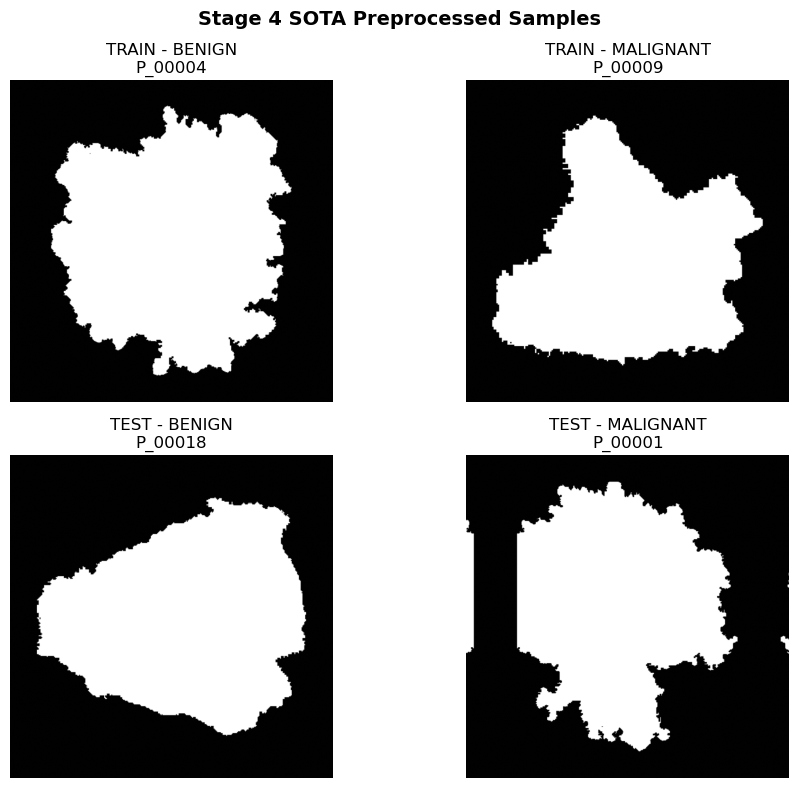


Visualization saved to: D:\Project\data\stage4_preprocessed\sample_visualization.png


In [17]:
if config.save_visualization:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle('Stage 4 SOTA Preprocessed Samples', fontsize=14, fontweight='bold')
    
    # Get sample images from each category
    samples = {
        ('train', 'benign'): [],
        ('train', 'malignant'): [],
        ('test', 'benign'): [],
        ('test', 'malignant'): []
    }
    
    for record in all_records:
        if record.processed_path and os.path.exists(record.processed_path):
            key = (record.split, record.label)
            if len(samples[key]) < 1:
                samples[key].append(record)
    
    for (split, label), recs in samples.items():
        for rec in recs:
            row = 0 if split == 'train' else 1
            col = 0 if label == 'benign' else 1
            
            img = cv2.imread(rec.processed_path, cv2.IMREAD_GRAYSCALE)
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(f"{split.upper()} - {label.upper()}\n{rec.patient_id}")
            axes[row, col].axis('off')
    
    plt.tight_layout()
    viz_path = os.path.join(config.output_root, 'sample_visualization.png')
    plt.savefig(viz_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nVisualization saved to: {viz_path}")

## 13. Final Summary

In [18]:
print("\n" + "=" * 70)
print("STAGE 4 PREPROCESSING COMPLETE - FINAL SUMMARY")
print("=" * 70)
print()
print("DATASET STATISTICS:")
print("-" * 40)
print(f"  Total images processed:  {total_stats.processed_images}")
print(f"  Failed images:           {total_stats.failed_images}")
print(f"  Artifacts removed:       {total_stats.artifacts_removed}")
print()
print("CLASS DISTRIBUTION:")
print("-" * 40)
print(f"  Train - Benign:     {total_stats.train_benign}")
print(f"  Train - Malignant:  {total_stats.train_malignant}")
print(f"  Test  - Benign:     {total_stats.test_benign}")
print(f"  Test  - Malignant:  {total_stats.test_malignant}")
print()
print("SOTA PREPROCESSING TECHNIQUES APPLIED:")
print("-" * 40)
print("  1. Artifact Removal (Shen et al., 2019)")
print("  2. Breast Segmentation (Wang et al., 2020)")
print("  3. ROI Extraction (Wu et al., 2019)")
print("  4. CLAHE Enhancement (Pizer et al., 1987)")
print("  5. Breast-Only Normalization (Shen et al., 2021)")
print(f"  6. High Resolution Output ({config.target_size[0]}x{config.target_size[1]})")
print()
print("OUTPUT FILES:")
print("-" * 40)
print(f"  Preprocessed images: {config.output_root}")
print(f"  Metadata CSV:        {metadata_path}")
print(f"  View pairs CSV:      {view_pairs_path}")
print(f"  Statistics JSON:     {stats_path}")
print()
print(f"Processing time: {total_stats.processing_time_seconds:.1f} seconds")
print("=" * 70)
print("\nReady for Stage 4 model training!")


STAGE 4 PREPROCESSING COMPLETE - FINAL SUMMARY

DATASET STATISTICS:
----------------------------------------
  Total images processed:  3568
  Failed images:           0
  Artifacts removed:       3484

CLASS DISTRIBUTION:
----------------------------------------
  Train - Benign:     1684
  Train - Malignant:  1155
  Test  - Benign:     427
  Test  - Malignant:  302

SOTA PREPROCESSING TECHNIQUES APPLIED:
----------------------------------------
  1. Artifact Removal (Shen et al., 2019)
  2. Breast Segmentation (Wang et al., 2020)
  3. ROI Extraction (Wu et al., 2019)
  4. CLAHE Enhancement (Pizer et al., 1987)
  5. Breast-Only Normalization (Shen et al., 2021)
  6. High Resolution Output (768x768)

OUTPUT FILES:
----------------------------------------
  Preprocessed images: D:\Project\data\stage4_preprocessed
  Metadata CSV:        D:\Project\data\stage4_preprocessed\metadata.csv
  View pairs CSV:      D:\Project\data\stage4_preprocessed\view_pairs.csv
  Statistics JSON:     D:\Pro